In [1]:
import numpy as np
import matplotlib.pyplot as plt
import micrograd
%matplotlib inline
import micrograd

In [ ]:
def f(x):
    return 3*x**2 - 4*x + 5

In [ ]:
f(3.0)

In [ ]:
xs=np.arange(-5.0,5.0, 0.25)
xs
f(xs)

In [ ]:
plt.plot(xs, f(xs))

In [ ]:
h=0.00000001
x=2/3
(f(x+h)-f(x))/h

In [ ]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
d

In [ ]:
h=0.00001
a=2.0
b=-3.0
c=10.0
d=a*b+c
c+=h
d1=a*b+c
print(d)
print(d1)
print(f"Slope :{(d1-d)/h}")

In [38]:
class Value:
    def __init__(self, data, _children=(), _op='',label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None 
    def __radd__(self, other):
        return self+other
    def __add__(self, other):
        other =other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        out._backward = _backward
        return out
    def __rmul__(self, other):#other* self => changes this format to self*other
        return self*other
    def __pow__(self, other):
       assert isinstance(other, (int, float)), "only supporting int/float powers for now"
       out = Value(self.data ** other, (self,), f'**{other}')
       def _backward():
            self.grad=other*(self.data**(other-1))*out.grad
       out._backward=_backward
       return out
    def __mul__(self, other):
        other=other if isinstance(other,Value) else Value(other)
        
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad+=out.grad*other.data
            other.grad+=out.grad*self.data
        out._backward = _backward
        return out
    def __truediv__(self, other):
        return self*(other**-1)
    def __repr__(self):
        return f"Value(data={self.data})"
    def tanh(self):
        x = self.data
        t=(np.exp(2*x)-1)/(np.exp(2*x)+1)
        out=Value(t, (self,), 'tanh')
        def _backward():
            self.grad+=(1-(t**2))*out.grad
        out._backward=_backward
        return out
    def __neg__(self):
        return self*(-1)
    def __sub__(self, other):
        return self+(-other)
    def exp(self):
        x = self.data
        out = Value(np.exp(x), (self,), 'exp')
        def _backward():
            self.grad+=out.data*out.grad
        out._backward=_backward
        return out
    def backward(self):
    
     topo = []
     visited = set()
     def build_topo(v):
       if v not in visited:
         visited.add(v)
         for child in v._prev:
           build_topo(child)
         topo.append(v)
     build_topo(self)
    
     self.grad = 1.0
     for node in reversed(topo):
       node._backward()
    

In [40]:
a=Value(2.0, label='a')
b=Value(3.0, label='b')
a-b

Value(data=-1.0)

In [31]:
a=Value(2.0)
a.exp()


Value(data=7.38905609893065)

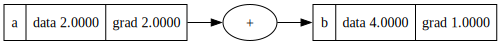

In [9]:
a=Value(2.0, label='a')
b=a+a ;b.label='b'
b.backward()
draw_dot(b)

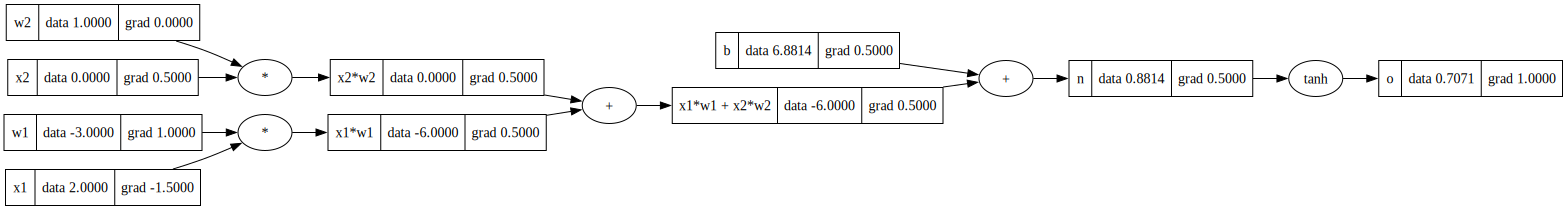

In [132]:
draw_dot(o)

In [28]:
a=Value(2.0)
1+a

Value(data=3.0)

In [ ]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e= a * b;e.label = 'e'
d = e + c;d.label = 'd'
f=Value(-2.0, label='f')
L=d * f;L.label = 'L'
print(L)

In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{%s | data %.4f  |grad %.4f }" % (n.label, n.data,n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:

draw_dot(L)

In [ ]:
a.data+=0.001*a.grad
b.data+=0.001*b.grad
c.data+=0.001*c.grad
f.data+=0.001*f.grad
e= a * b
d= e + c
L= d * f
print(L.data)

In [ ]:
# dl/da=dl/dd*dd/de*de/da
# dl/dd=1
#dd/de=f
#
a.grad=e.grad*-3.0
b.grad=e.grad*2.0

In [ ]:
#dl/de=dd/de*dl/dd
#dl/dc=dd/dc*dl/dd

e.grad=f.data
c.grad=f.data

In [ ]:
L.grad=1.0  

In [ ]:
#dl/df=d
#dl/dd=f
f.grad=4.0
d.grad=-2.0

In [ ]:
def lol():
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e= a * b;e.label = 'e'
    d = e + c;d.label = 'd'
    f=Value(-2.0, label='f')
    L=d * f;L.label = 'L'
    L1=L.data
    h=0.00001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
   
    e= a * b;e.label = 'e'
    d = e + c;d.label = 'd'
    f=Value(-2.0, label='f')
    L0=d * f;L.label = 'L'
    L2=L0.data
    print((L2-L1)/h)
    

In [ ]:
L.grad=1.0

In [ ]:
lol()

In [ ]:
plt.plot(np.arange(-5.0,5.0, 0.25),np.tanh(np.arange(-5.0,5.0, 0.25)))
;plt.grid();


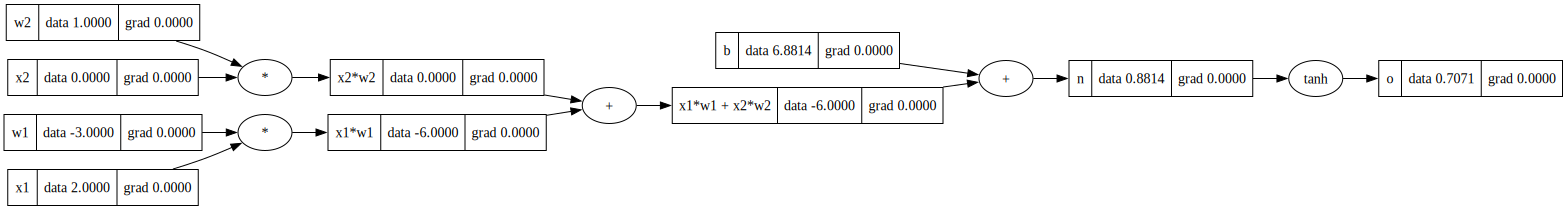

In [4]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o=n.tanh();o.label = 'o'
draw_dot(o)


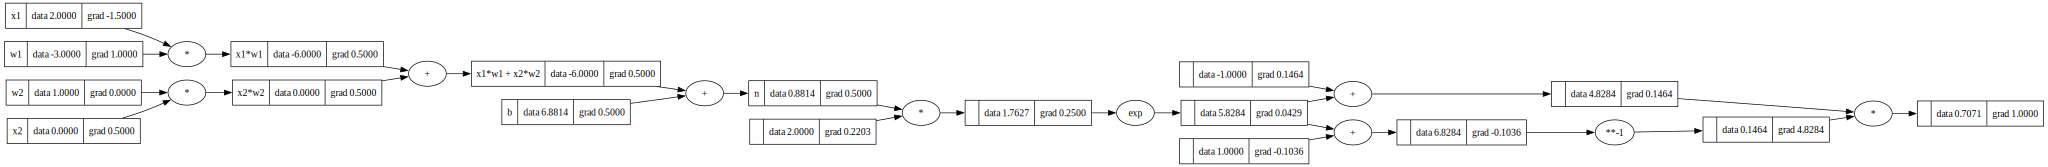

In [42]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#-----------------
e=(2*n).exp()
o=(e-1)/(e+1)
#(e**2n)+1/e**2n-1
#o=n.tanh();o.label = 'o'
o.backward()
draw_dot(o)

In [173]:
o.backward()

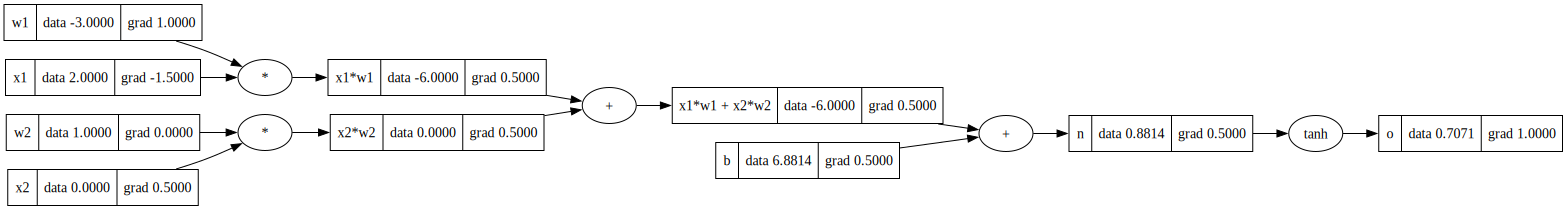

In [174]:
draw_dot(o)

In [5]:
o.backward()

In [163]:
o.grad=1.0
topo=[]
visited=set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
for node in reversed(topo):
    node._backward()

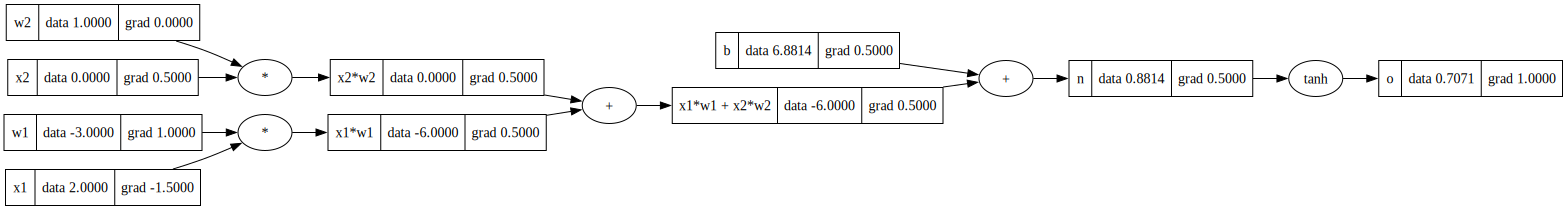

In [6]:
draw_dot(o)

In [159]:
topo=[]
visited=set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [157]:
#nothing will happen because b has no children nodes so it will not contribute to the gradient of o but we can still call backward on b but nothing will happen because b has no children nodes so it will not contribute to the gradient of o but we can still call backward on b
b._backward()

In [155]:
x2w2._backward()

In [153]:
x1w1._backward()

In [152]:
x1w1x2w2._backward()

In [151]:
n._backward()

In [150]:

o._backward()

In [149]:
o.grad=1.0

In [120]:
#tanh(n)=0.7071
#do/dn=1-tanh(n)**2
#do/dn=1-0.7071**2
n.grad=1-0.7071**2

In [122]:
b.grad=n.grad*1.0
x1w1x2w2.grad=n.grad*1.0

In [125]:
x2w2.grad=0.5
x1w1.grad=0.5

In [129]:
w2.grad=x2w2.grad*x2.data
x2.grad=x2w2.grad*w2.data

In [131]:
w1.grad=x1w1.grad*x1.data
x1.grad=x1w1.grad*w1.data

In [43]:
import torch

In [58]:
# Case is true because by default pytorch makes it false bcz we dont want gradient for the for effeciency for the inputs i.e leaf nodes
#python is using double precision by default for its floating points number but by default data type of these tensors is float32 so we need to change it to double precision by using .double() method

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [71]:
b.grad

tensor([0.5000], dtype=torch.float64)

In [57]:
torch.tensor([1.0]).dtype

torch.float32

In [72]:
import random

In [127]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(np.random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self, x):
        act=sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out=act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [144]:
x= [2.0, 3.0, -1.0]
n=MLP(3,[4,4,1])
n(x)

Value(data=-0.08994281766060096)

In [129]:
len(n.parameters())

41

In [ ]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

In [145]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [93]:
#draw_dot(n(x))

In [214]:
for k in range(30):
#forward pass
 ypreds=[n(x) for x in xs]
loss=sum([(yout-ygt)**2 for ygt,yout in zip(ys,ypreds)])
#backward pass
for p in n.parameters():
    p.grad=0.0
loss.backward()
#update
for p in n.parameters():
    p.data += -0.1*p.grad
print(k, loss.data)


29 0.0023684557995772054


In [215]:
ypreds

[Value(data=0.9734123281452005),
 Value(data=-0.9808286471453159),
 Value(data=-0.9691323256954347),
 Value(data=0.9815284700777877)]

In [131]:
loss.backward()

In [133]:
n.layers[0].neurons[0].w[0].grad

0.0

In [134]:
n.layers[0].neurons[0].w[0].data

0.3131697625060379

In [112]:
#draw_dot(loss)

In [136]:
for p in n.parameters():
    p.data += 0.1*p.grad 